### Формирование модели машинного обучения

Текущий ноутбук рассматривает анализ датасета [Auto MPG](https://archive.ics.uci.edu/ml/datasets/Auto+MPG).

В работе рассматривается:
1. обучение регрессионной модели для определения потребления автомобилями топлива в городском цикле в галлонах на милю по представленным данным;
2. сохранение обученной модели в виде **конвейера обработки данных** для последующего использования.

In [1]:
import numpy as np
import pandas as pd
from seaborn import pairplot
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from pickle import dump
from pathlib import Path

In [2]:
import sklearn
import sys
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(sys.version)

numpy: 2.4.4
pandas: 3.0.2
scikit-learn: 1.8.0
3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]


In [3]:
df1 = pd.read_csv("C:/ovs/lab1/data/customer_churn_dataset-testing-master.csv")
df2 = pd.read_csv("C:/ovs/lab1/data/customer_churn_dataset-training-master.csv")
df_all = pd.concat([df1, df2], ignore_index=True)
#col_names = ("mpg", "cylinders", "displacement", "horsepower", "weight", 
#             "acceleration", "model_year", "origin", "car name")

In [4]:
df_all

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.00,9.0,1.0
1,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.00,20.0,0.0
2,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.00,21.0,0.0
3,4.0,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.00,18.0,0.0
4,5.0,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.00,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
505203,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
505204,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
505205,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [5]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  str    
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  str    
 8   Contract Length    505206 non-null  str    
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), str(3)
memory usage: 46.3 MB


In [6]:
df_all = df_all.loc[:, ['Age', 'Support Calls', 'Payment Delay', 'Total Spend', 'Subscription Type', 'Contract Length', 'Churn']]

In [7]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                505206 non-null  float64
 1   Support Calls      505206 non-null  float64
 2   Payment Delay      505206 non-null  float64
 3   Total Spend        505206 non-null  float64
 4   Subscription Type  505206 non-null  str    
 5   Contract Length    505206 non-null  str    
 6   Churn              505206 non-null  float64
dtypes: float64(5), str(2)
memory usage: 27.0 MB


Посмотрим на строку с Null значением. 

In [8]:
df_all[df_all.isna().any(axis=1)]

,Age,Support Calls,Payment Delay,Total Spend,Subscription Type,Contract Length,Churn
263669,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удалим данную строку, т.к. значений в данной строке нет

In [9]:
df_all = df_all.dropna()

In [10]:
df_all = df_all.rename(columns={
    'Support Calls': 'Support_Calls',
    'Payment Delay': 'Payment_Delay',
    'Total Spend': 'Total_Spend',
    'Subscription Type': 'Subscription_Type',
    'Contract Length': 'Contract_Length'
})

Посмотрим на распределение данных. Какие выводы по ним можно сделать?

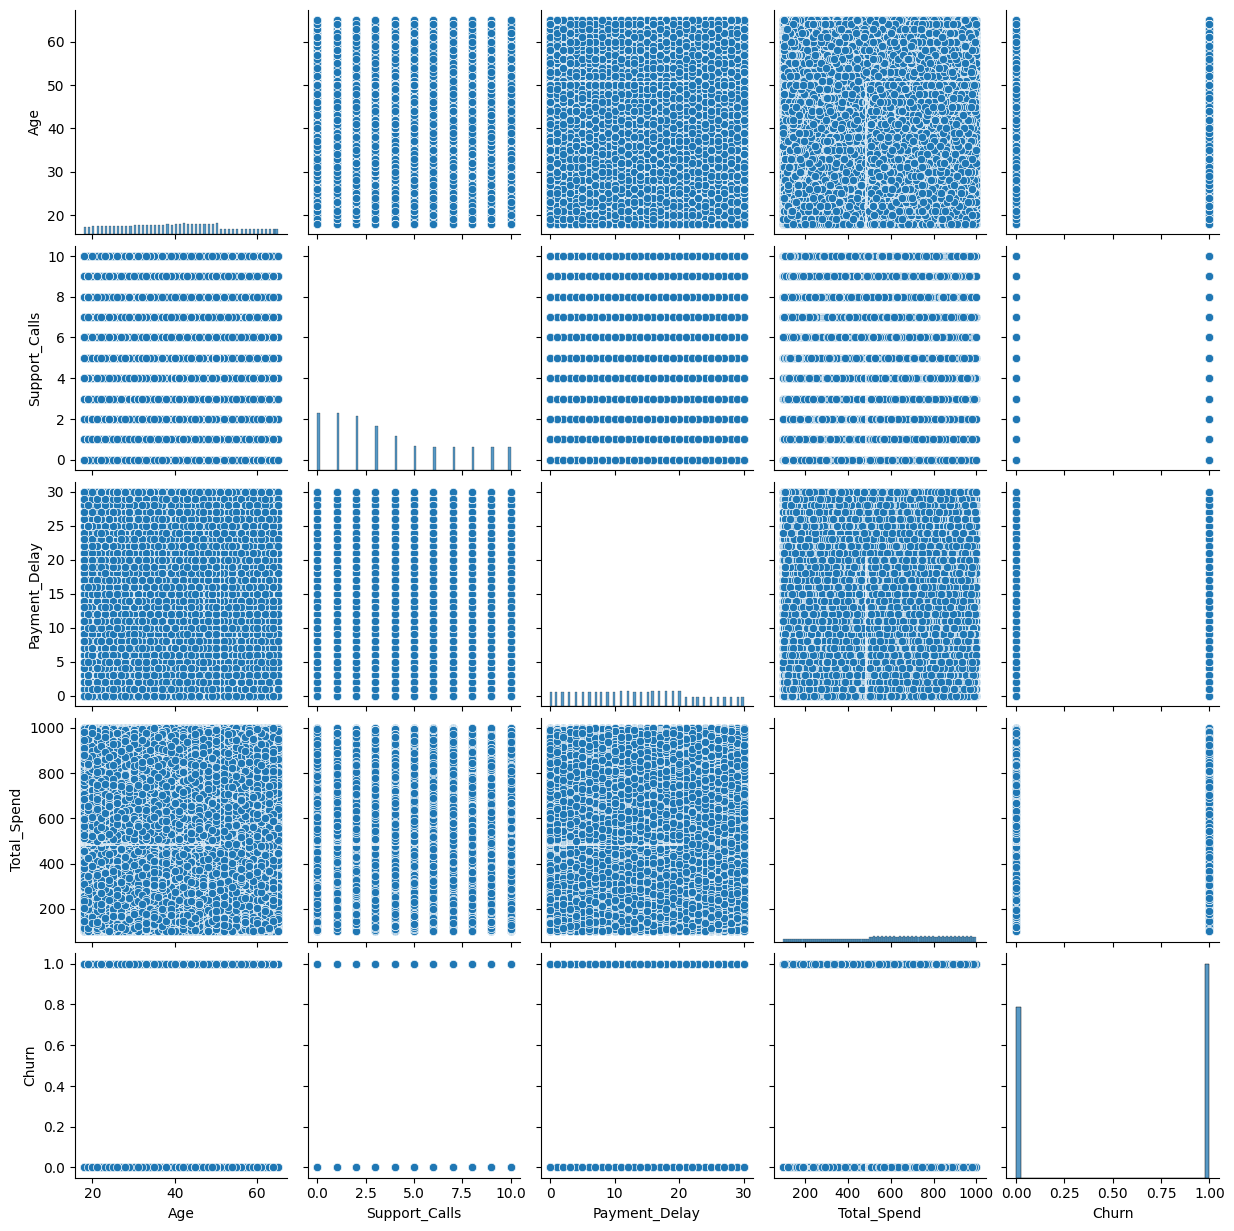

In [11]:
pairplot(df_all)

Посмторим на распределение категориальных переменных.

In [12]:
df_all["Subscription_Type"].value_counts()

Subscription_Type
Standard    170630
Premium     170099
Basic       164477
Name: count, dtype: int64

In [13]:
df_all["Contract_Length"].value_counts()

Contract_Length
Annual       198608
Quarterly    197364
Monthly      109234
Name: count, dtype: int64

Выясним, содержатся ли выбросы в данных.

<Axes: >

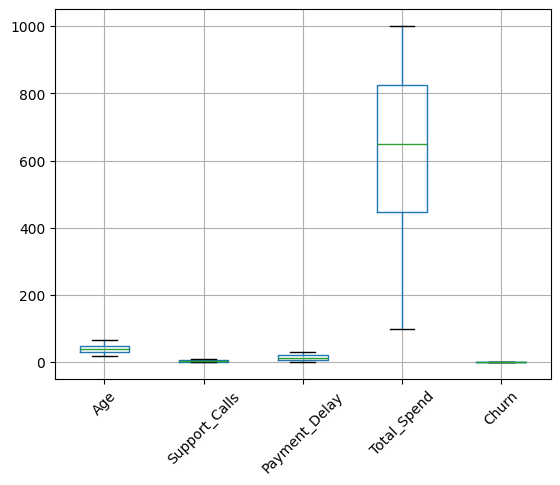

In [14]:
df_all[['Age', 'Support_Calls', 'Payment_Delay', 'Total_Spend', 'Churn']].boxplot(rot=45)

Выбросы есть, но их немного, и они не критичные. Убирать их не будем.

Сформируем конвейеры для обработки количественных и категориальных данных.

In [15]:
numeric_features = ['Age', 'Support_Calls', 'Payment_Delay', 'Total_Spend']
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [16]:
categorical_features = ['Subscription_Type', 'Contract_Length']
categorical_transformer = Pipeline(
    steps=[
        ("onehot-encoder", OneHotEncoder(drop="first", 
                                         handle_unknown="ignore")),
    ]
)

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

In [18]:
classifier = LogisticRegression(max_iter=1000, random_state=42)
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier)
])

In [19]:
train, test = train_test_split(df_all, test_size=0.3)

In [20]:
train.head()

,Age,Support_Calls,Payment_Delay,Total_Spend,Subscription_Type,Contract_Length,Churn
271730,35.0,1.0,10.0,203.85,Premium,Quarterly,1.0
433446,36.0,2.0,5.0,586.35,Standard,Quarterly,0.0
198078,62.0,8.0,19.0,937.00,Basic,Monthly,1.0
408581,34.0,1.0,14.0,971.64,Premium,Annual,0.0
73721,34.0,10.0,13.0,792.00,Standard,Quarterly,1.0


In [21]:
X_train = train[['Age', 'Support_Calls', 'Payment_Delay', 'Total_Spend', 'Subscription_Type', 'Contract_Length']]
Y_train = train[["Churn"]]

In [22]:
X_test = test[['Age', 'Support_Calls', 'Payment_Delay', 'Total_Spend', 'Subscription_Type', 'Contract_Length']]
Y_test = test[["Churn"]]

Подберем коэффициент регуляризации для линейной регрессии.

In [23]:
param_grid = {
    "classifier__C": np.logspace(-3, 2, 10),  # обратная регуляризация для LogisticRegression
    "classifier__penalty": ['l1', 'l2'],
    "classifier__solver": ['liblinear', 'saga'],
}

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
search_cv = GridSearchCV(
    pipe, 
    param_grid, 
    cv=cv, 
    scoring='roc_auc',  # Основная метрика для churn
    n_jobs=-1,
    verbose=1
)

In [26]:
search_cv.fit(X_train, Y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


C:\Users\Роман\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Роман\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Роман\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.0000...00000000e+02]), 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [27]:
print("Best params:")
print(search_cv.best_params_)

Best params:
{'classifier__C': np.float64(100.0), 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


In [28]:
search_cv.score(X_train, Y_train)

0.9033436394762001

In [29]:
search_cv.score(X_test, Y_test)

0.9023593558019614

Сохраним полученный конвейер обработки данных для дальнейшего использования.

In [30]:
Path("../models").mkdir(parents=True, exist_ok=True)

with open("../models/pipeline.pkl", "wb") as file:
    dump(search_cv, file)